In [1]:
"""
Flow.ipynb
==========
Main entry point for the QFlow(4e,4o) replication.

Runs all four benchmark cases from Table I of Kowalski & Bauman
(arXiv:2305.05168v2), collects converged QFlow energies, computes
all classical reference energies, and prints the complete Table I.  

Run cells 1-4 in any order — each case is independent.
Run cell 5 only after all four cases have completed.
"""

import os
import matplotlib.pyplot as plt
import numpy as np

OUTS = "outs"
os.makedirs(OUTS, exist_ok=True)

from qflow import (
    run_qflow,
    make_h_chain,
    build_refstate,
    compute_hf_energy,
    compute_fci_energy,
    compute_casci_energy,
    compute_ccsd_energy_pyscf,
    compute_ccsdt_energy_ccpy,
    compute_ccsdtq_energy_ccpy,
)

qflow_results = {}  # populated by cells 1-4

In [2]:
"""Case 1 — H6, R = 2.0 bohr (weakly correlated)"""

history_h6_r2, spreads_h6_r2, grads_h6_r2 = run_qflow(
    6, 2.0,
    lr=0.25,
    max_cycles=40,
    conv_spread=2e-5,
    debug_cycles=1,
)

qflow_results["H6_R2"] = history_h6_r2[-1][0]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
E_primary   = [row[0] for row in history_h6_r2]
spread_mha  = [s * 1e3 for s in spreads_h6_r2]
gvals       = [g for g in grads_h6_r2 if g is not None]
axes[0].semilogy(spread_mha); axes[0].axhline(2.0, ls="--")
axes[0].set(xlabel="Cycle", ylabel="Spread (mHa)", title="H6 R=2.0 — Spread")
axes[1].plot(E_primary)
axes[1].set(xlabel="Cycle", ylabel="E_primary (Ha)", title="H6 R=2.0 — Energy")
if gvals:
    axes[2].semilogy(range(1, 1+len(gvals)), gvals)
axes[2].set(xlabel="Cycle", ylabel="max|grad|", title="H6 R=2.0 — Gradient")
plt.tight_layout()
plt.savefig(f"{OUTS}/qflow_H6_R2.0.png", dpi=150)
plt.show()
print(f"QFlow H6 R=2.0 -> {qflow_results['H6_R2']:.8f} Ha")


  QFlow(4e,4o)  —  H6  R = 2.0 bohr
  lr=0.25  max_cycles=40  conv_spread=0.02 mHa

[ Setup ] Building molecule and running RHF...
converged SCF energy = -3.10585013034765
          nmo=6  nelec=6  E_nuc=4.350000  E_RHF=-3.105850
[ Setup ] Building FCI bitstring basis...
          FCI dim = 20x20 = 400
[ Setup ] Enumerating SES...
          M=9 SES   Primary: occ=(1, 2) vir=(3, 4)
[ Setup ] Initialising global pool...
          Pool size: 198 keys
[ Setup ] Precomputing SES data...
          Done.


[ Amplitude Ownership — first-claimant rule (Eq. 18) ]
  ('x', (2, 3), (6, 7))                          ->  SES-00 occ(1, 2) vir(3, 4)
  ('x', (2, 3), (6, 9))                          ->  SES-00 occ(1, 2) vir(3, 4)
  ('x', (2, 3), (7, 8))                          ->  SES-00 occ(1, 2) vir(3, 4)
  ('x', (2, 3), (8, 9))                          ->  SES-00 occ(1, 2) vir(3, 4)
  ('x', (2, 3, 4), (6, 7, 8))                    ->  SES-00 occ(1, 2) vir(3, 4)
  ('x', (2, 3, 4), (6, 8, 9))          

KeyboardInterrupt: 


  QFlow(4e,4o)  —  H6  R = 3.0 bohr
  lr=0.4  max_cycles=40  conv_spread=0.02 mHa

[ Setup ] Building molecule and running RHF...
converged SCF energy = -2.67543226271603
          nmo=6  nelec=6  E_nuc=2.900000  E_RHF=-2.675432
[ Setup ] Building FCI bitstring basis...
          FCI dim = 20x20 = 400
[ Setup ] Enumerating SES...
          M=9 SES   Primary: occ=(1, 2) vir=(3, 4)
[ Setup ] Initialising global pool...
          Pool size: 198 keys
[ Setup ] Precomputing SES data...
          Done.


[ Amplitude Ownership — first-claimant rule (Eq. 18) ]
  ('x', (2, 3), (6, 7))                          ->  SES-00 occ(1, 2) vir(3, 4)
  ('x', (2, 3), (6, 9))                          ->  SES-00 occ(1, 2) vir(3, 4)
  ('x', (2, 3), (7, 8))                          ->  SES-00 occ(1, 2) vir(3, 4)
  ('x', (2, 3), (8, 9))                          ->  SES-00 occ(1, 2) vir(3, 4)
  ('x', (2, 3, 4), (6, 7, 8))                    ->  SES-00 occ(1, 2) vir(3, 4)
  ('x', (2, 3, 4), (6, 8, 9))           

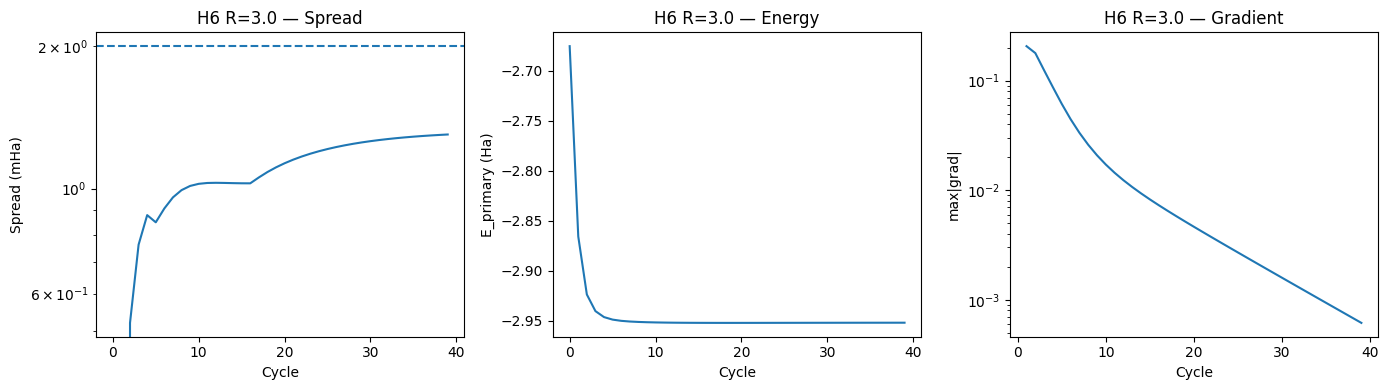

QFlow H6 R=3.0 -> -2.95219572 Ha


In [3]:
"""Case 2 — H6, R = 3.0 bohr (strongly correlated)"""

history_h6_r3, spreads_h6_r3, grads_h6_r3 = run_qflow(
    6, 3.0,
    lr=0.4,
    max_cycles=40,
    conv_spread=2e-5,
    debug_cycles=1,
)

qflow_results["H6_R3"] = history_h6_r3[-1][0]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
E_primary   = [row[0] for row in history_h6_r3]
spread_mha  = [s * 1e3 for s in spreads_h6_r3]
gvals       = [g for g in grads_h6_r3 if g is not None]
axes[0].semilogy(spread_mha); axes[0].axhline(2.0, ls="--")
axes[0].set(xlabel="Cycle", ylabel="Spread (mHa)", title="H6 R=3.0 — Spread")
axes[1].plot(E_primary)
axes[1].set(xlabel="Cycle", ylabel="E_primary (Ha)", title="H6 R=3.0 — Energy")
if gvals:
    axes[2].semilogy(range(1, 1+len(gvals)), gvals)
axes[2].set(xlabel="Cycle", ylabel="max|grad|", title="H6 R=3.0 — Gradient")
plt.tight_layout()
plt.savefig(f"{OUTS}/qflow_H6_R3.0.png", dpi=150)
plt.show()
print(f"QFlow H6 R=3.0 -> {qflow_results['H6_R3']:.8f} Ha")


  QFlow(4e,4o)  —  H8  R = 2.0 bohr
  lr=0.1  max_cycles=40  conv_spread=0.02 mHa

[ Setup ] Building molecule and running RHF...
converged SCF energy = -4.13819927490616
          nmo=8  nelec=8  E_nuc=6.871429  E_RHF=-4.138199
[ Setup ] Building FCI bitstring basis...
          FCI dim = 70x70 = 4900
[ Setup ] Enumerating SES...
          M=36 SES   Primary: occ=(2, 3) vir=(4, 5)
[ Setup ] Initialising global pool...
          Pool size: 684 keys
[ Setup ] Precomputing SES data...
          Done.


[ Amplitude Ownership — first-claimant rule (Eq. 18) ]
  ('x', (4, 5), (10, 11))                        ->  SES-00 occ(2, 3) vir(4, 5)
  ('x', (4, 5), (8, 11))                         ->  SES-00 occ(2, 3) vir(4, 5)
  ('x', (4, 5), (8, 9))                          ->  SES-00 occ(2, 3) vir(4, 5)
  ('x', (4, 5), (9, 10))                         ->  SES-00 occ(2, 3) vir(4, 5)
  ('x', (4, 5, 6), (8, 10, 11))                  ->  SES-00 occ(2, 3) vir(4, 5)
  ('x', (4, 5, 6), (8, 9, 10))        

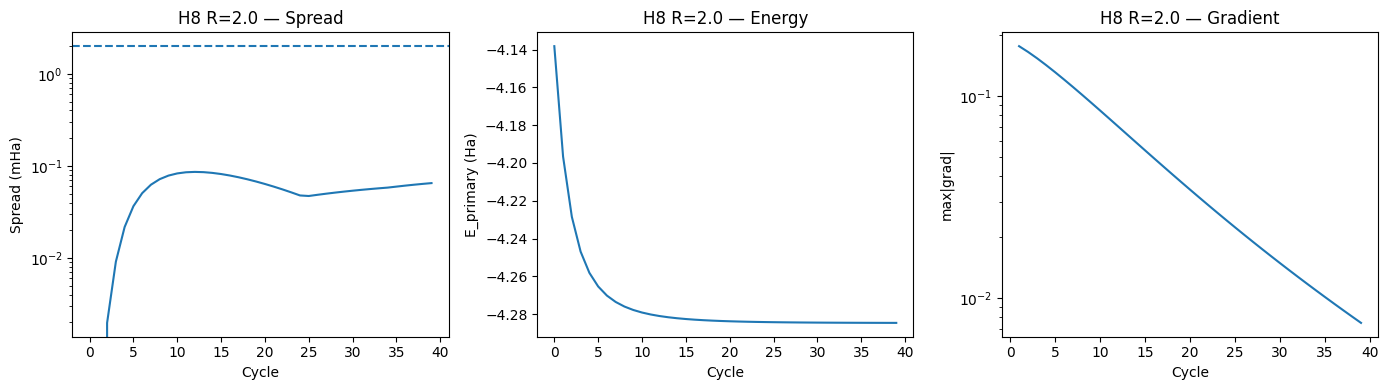

QFlow H8 R=2.0 -> -4.28462734 Ha


In [4]:
"""Case 3 — H8, R = 2.0 bohr (weakly correlated)"""

history_h8_r2, spreads_h8_r2, grads_h8_r2 = run_qflow(
    8, 2.0,
    lr=0.1,
    max_cycles=40,
    conv_spread=2e-5,
    debug_cycles=1,
)

qflow_results["H8_R2"] = history_h8_r2[-1][0]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
E_primary   = [row[0] for row in history_h8_r2]
spread_mha  = [s * 1e3 for s in spreads_h8_r2]
gvals       = [g for g in grads_h8_r2 if g is not None]
axes[0].semilogy(spread_mha); axes[0].axhline(2.0, ls="--")
axes[0].set(xlabel="Cycle", ylabel="Spread (mHa)", title="H8 R=2.0 — Spread")
axes[1].plot(E_primary)
axes[1].set(xlabel="Cycle", ylabel="E_primary (Ha)", title="H8 R=2.0 — Energy")
if gvals:
    axes[2].semilogy(range(1, 1+len(gvals)), gvals)
axes[2].set(xlabel="Cycle", ylabel="max|grad|", title="H8 R=2.0 — Gradient")
plt.tight_layout()
plt.savefig(f"{OUTS}/qflow_H8_R2.0.png", dpi=150)
plt.show()
print(f"QFlow H8 R=2.0 -> {qflow_results['H8_R2']:.8f} Ha")


  QFlow(4e,4o)  —  H8  R = 3.0 bohr
  lr=0.1  max_cycles=40  conv_spread=0.02 mHa

[ Setup ] Building molecule and running RHF...
converged SCF energy = -3.57234732073291
          nmo=8  nelec=8  E_nuc=4.580952  E_RHF=-3.572347
[ Setup ] Building FCI bitstring basis...
          FCI dim = 70x70 = 4900
[ Setup ] Enumerating SES...
          M=36 SES   Primary: occ=(2, 3) vir=(4, 5)
[ Setup ] Initialising global pool...
          Pool size: 684 keys
[ Setup ] Precomputing SES data...
          Done.


[ Amplitude Ownership — first-claimant rule (Eq. 18) ]
  ('x', (4, 5), (10, 11))                        ->  SES-00 occ(2, 3) vir(4, 5)
  ('x', (4, 5), (8, 11))                         ->  SES-00 occ(2, 3) vir(4, 5)
  ('x', (4, 5), (8, 9))                          ->  SES-00 occ(2, 3) vir(4, 5)
  ('x', (4, 5), (9, 10))                         ->  SES-00 occ(2, 3) vir(4, 5)
  ('x', (4, 5, 6), (8, 10, 11))                  ->  SES-00 occ(2, 3) vir(4, 5)
  ('x', (4, 5, 6), (8, 9, 10))        

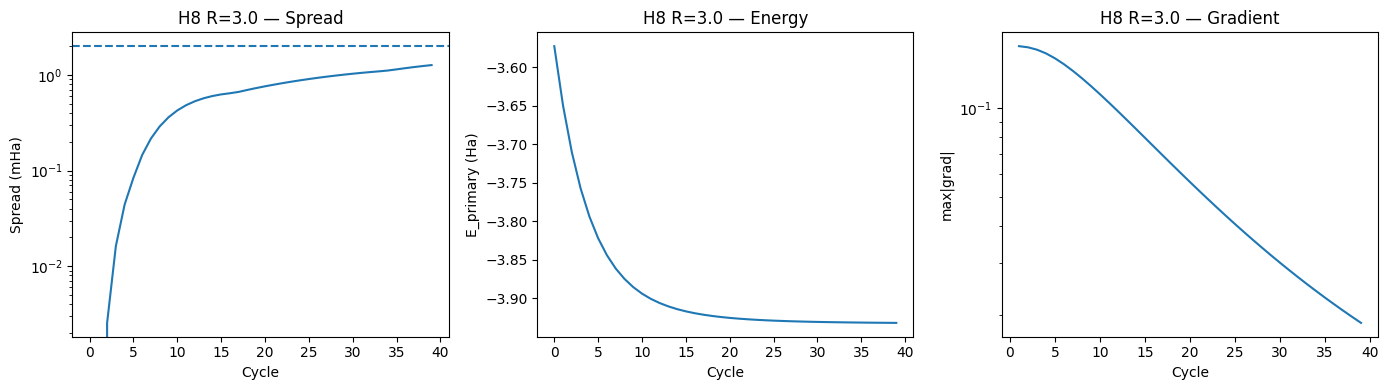

QFlow H8 R=3.0 -> -3.93199291 Ha


In [5]:
"""Case 4 — H8, R = 3.0 bohr (strongly correlated)"""

history_h8_r3, spreads_h8_r3, grads_h8_r3 = run_qflow(
    8, 3.0,
    lr=0.1,
    max_cycles=40,
    conv_spread=2e-5,
    debug_cycles=1,
)

qflow_results["H8_R3"] = history_h8_r3[-1][0]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
E_primary   = [row[0] for row in history_h8_r3]
spread_mha  = [s * 1e3 for s in spreads_h8_r3]
gvals       = [g for g in grads_h8_r3 if g is not None]
axes[0].semilogy(spread_mha); axes[0].axhline(2.0, ls="--")
axes[0].set(xlabel="Cycle", ylabel="Spread (mHa)", title="H8 R=3.0 — Spread")
axes[1].plot(E_primary)
axes[1].set(xlabel="Cycle", ylabel="E_primary (Ha)", title="H8 R=3.0 — Energy")
if gvals:
    axes[2].semilogy(range(1, 1+len(gvals)), gvals)
axes[2].set(xlabel="Cycle", ylabel="max|grad|", title="H8 R=3.0 — Gradient")
plt.tight_layout()
plt.savefig(f"{OUTS}/qflow_H8_R3.0.png", dpi=150)
plt.show()
print(f"QFlow H8 R=3.0 -> {qflow_results['H8_R3']:.8f} Ha")

In [6]:
"""
Table I — Full comparison.
Run this cell after all four QFlow cases have completed.
Reference energies are computed fresh here so this cell is self-contained.
"""

cases = {
    "H6_R2": (6, 2.0),
    "H6_R3": (6, 3.0),
    "H8_R2": (8, 2.0),
    "H8_R3": (8, 3.0),
}

method_order = ["HF", "CAS-ED", "CCSD", "CCSDT", "CCSDTQ", "QFlow(4e,4o)", "ED"]

all_results = {}
for key, (nH, R) in cases.items():
    mol = make_h_chain(nH, R)
    ref = build_refstate(mol, symmetry_subgroup="D2h")
    all_results[key] = {
        "HF":           compute_hf_energy(ref),
        "CAS-ED":       compute_casci_energy(ref, ncas=4, nelecas=4),
        "CCSD":         compute_ccsd_energy_pyscf(ref),
        "CCSDT":        compute_ccsdt_energy_ccpy(ref, nfrozen=0),
        "CCSDTQ":       compute_ccsdtq_energy_ccpy(ref, nfrozen=0),
        "QFlow(4e,4o)": qflow_results.get(key, float("nan")),
        "ED":           compute_fci_energy(ref),
    }

col_labels = ["H6 (2.0 a.u)", "H6 (3.0 a.u)", "H8 (2.0 a.u)", "H8 (3.0 a.u)"]
col_keys   = ["H6_R2", "H6_R3", "H8_R2", "H8_R3"]
col_w      = 14

header = f"{'Method':<16}" + "".join(f"{c:>{col_w}}" for c in col_labels)
sep    = "-" * len(header)
print("\nTable I — Converged energies (Hartree)")
print(sep)
print(header)
print(sep)
for method in method_order:
    row = f"{method:<16}"
    for k in col_keys:
        val = all_results[k].get(method, float("nan"))
        row += f"{val:>{col_w}.4f}"
    print(row)
print(sep)

converged SCF energy = -3.10585013034765
CASCI E = -3.16693813270478  E(CI) = -3.54776991259136  S^2 = 0.0000000
E(CCSD) = -3.217277205958934  E_corr = -0.1114270756112839
CCpy git commit ID cd N/A
   ------------------------------------------
   method = CCSDT
   maximum_iterations = 80
   amp_convergence = 1e-07
   energy_convergence = 1e-07
   energy_shift = 0.0
   diis_size = 6
   RHF_symmetry = True
   diis_out_of_core = False
   davidson_out_of_core = False
   amp_print_threshold = 0.09
   davidson_max_subspace_size = 30
   davidson_solver = standard
   davidson_selection_method = overlap
   ------------------------------------------

   CC calculation started on 2026-03-28 21:16:14
   Energy of initial guess =         0.0000000000

      Iter.     Residuum             δE                ΔE           Wall time       Memory
    -----------------------------------------------------------------------------------------
       0      0.2209665764     -0.0674911816     -0.0674911816    

fatal: not a git repository (or any parent up to mount point /)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


       4      0.0134726351     -0.0022480281     -0.1096054687     (0.0m 0.0s)    185.63 MB
       5      0.0084924223     -0.0011264584     -0.1107319271     (0.0m 0.0s)    185.63 MB
       6      0.0055457534     -0.0005994612     -0.1113313883     (0.0m 0.0s)    185.63 MB
       7      0.0001604595     -0.0008614134     -0.1121928017     (0.0m 0.0s)    185.63 MB
       8      0.0000441458     -0.0000044101     -0.1121972118     (0.0m 0.0s)    185.63 MB
       9      0.0000136948      0.0000006307     -0.1121965811     (0.0m 0.0s)    185.63 MB
      10      0.0000041894     -0.0000002666     -0.1121968477     (0.0m 0.0s)    185.64 MB
      11      0.0000010658     -0.0000000052     -0.1121968529     (0.0m 0.0s)    185.65 MB
      12      0.0000005534      0.0000000221     -0.1121968307     (0.0m 0.0s)    185.65 MB
      13      0.0000001255     -0.0000000065     -0.1121968372     (0.0m 0.0s)    185.65 MB
      14      0.0000000403     -0.0000000008     -0.1121968380     (0.0m 0.0s)  

fatal: not a git repository (or any parent up to mount point /)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


       0      0.2214293004     -0.0674911816     -0.0674911816     (0.0m 0.1s)    186.12 MB
       1      0.0891797007     -0.0245915137     -0.0920826953     (0.0m 0.1s)    186.12 MB
       2      0.0459001902     -0.0105528986     -0.1026355939     (0.0m 0.1s)    186.13 MB
       3      0.0263315466     -0.0046588701     -0.1072944639     (0.0m 0.1s)    186.13 MB
       4      0.0163774560     -0.0021835459     -0.1094780099     (0.0m 0.1s)    186.13 MB
       5      0.0106102720     -0.0010691996     -0.1105472095     (0.0m 0.1s)    186.13 MB
       6      0.0069806894     -0.0005537846     -0.1111009942     (0.0m 0.1s)    186.13 MB
       7      0.0002323012     -0.0007442794     -0.1118452735     (0.0m 0.1s)    186.13 MB
       8      0.0000631461     -0.0000045680     -0.1118498415     (0.0m 0.1s)    186.14 MB
       9      0.0000147127      0.0000015153     -0.1118483261     (0.0m 0.1s)    186.14 MB
      10      0.0000040086     -0.0000002326     -0.1118485587     (0.0m 0.1s)  

...

CCpy git commit ID cd N/A
   ------------------------------------------
   method = CCSDTQ
   maximum_iterations = 80
   amp_convergence = 1e-07
   energy_convergence = 1e-07
   energy_shift = 0.0
   diis_size = 6
   RHF_symmetry = True
   diis_out_of_core = False
   davidson_out_of_core = False
   amp_print_threshold = 0.09
   davidson_max_subspace_size = 30
   davidson_solver = standard
   davidson_selection_method = overlap
   ------------------------------------------

   CC calculation started on 2026-03-28 21:16:24
   Energy of initial guess =         0.0000000000

      Iter.     Residuum             δE                ΔE           Wall time       Memory
    -----------------------------------------------------------------------------------------
       0      0.2677306512     -0.0904935206     -0.0904935206     (0.0m 0.3s)     208.5 MB
       1      0.1053908143     -0.0313188145     -0.1218123351     (0.0m 0.3s)    212.51 MB
       2      0.0578456916     -0.0134764712     -0.1

fatal: not a git repository (or any parent up to mount point /)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


       5      0.0416165842     -0.0060853448     -0.3700070148     (0.0m 0.0s)    200.79 MB
       6      0.0354975766     -0.0040184464     -0.3740254612     (0.0m 0.1s)    200.79 MB
       7      0.0226732461     -0.0113006637     -0.3853261249     (0.0m 0.0s)    200.79 MB
       8      0.0172744015     -0.0047615931     -0.3900877180     (0.0m 0.0s)    200.79 MB
       9      0.0131316725     -0.0047169859     -0.3948047039     (0.0m 0.1s)    200.79 MB
      10      0.0101657266     -0.0027924571     -0.3975971610     (0.0m 0.1s)    200.79 MB
      11      0.0063027750     -0.0034181384     -0.4010152994     (0.0m 0.1s)    200.79 MB
      12      0.0034289628     -0.0027477300     -0.4037630294     (0.0m 0.1s)    200.79 MB
      13      0.0023120456     -0.0006781050     -0.4044411344     (0.0m 0.0s)    200.79 MB
      14      0.0014878394     -0.0004432790     -0.4048844135     (0.0m 0.1s)    200.79 MB
      15      0.0011302781     -0.0001779287     -0.4050623422     (0.0m 0.1s)  

fatal: not a git repository (or any parent up to mount point /)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


CCpy git commit ID cd N/A
   ------------------------------------------
   method = CCSDTQ
   maximum_iterations = 80
   amp_convergence = 1e-07
   energy_convergence = 1e-07
   energy_shift = 0.0
   diis_size = 6
   RHF_symmetry = True
   diis_out_of_core = False
   davidson_out_of_core = False
   amp_print_threshold = 0.09
   davidson_max_subspace_size = 30
   davidson_solver = standard
   davidson_selection_method = overlap
   ------------------------------------------

   CC calculation started on 2026-03-28 21:16:34
   Energy of initial guess =         0.0000000000

      Iter.     Residuum             δE                ΔE           Wall time       Memory
    -----------------------------------------------------------------------------------------
       0      0.4662581055     -0.1874746204     -0.1874746204     (0.0m 0.2s)    206.25 MB
       1      0.2801367995     -0.0918079629     -0.2792825832     (0.0m 0.3s)    210.25 MB
       2      0.1851301427     -0.0487612868     -0.3